# 23CSE301 Machine Learning — Capstone Project
# Regression Track — Loan Risk Score Prediction
### Review 1 · Section A (Dataset & EDA) and Section B (Preprocessing & Feature Engineering)

**Dataset:** `Loan.csv` (20,000 rows × 36 columns)
**Target variable:** `RiskScore` — a continuous credit-risk score assigned to each loan applicant.

> **Why `RiskScore` and not `LoanApproved`?** `LoanApproved` is a binary decision derived from the
> risk assessment (Pearson correlation with `RiskScore` ≈ **-0.77**, by far the strongest in the
> dataset) — it is downstream of the score, not a predictor of it, and it is reserved as the target
> for the Classification track. Using it as a regression *feature* would be direct target leakage,
> so it is dropped in Section B and never used as a predictor here.

This notebook covers **only** rubric Sections A and B (Sections C–E, model training/tuning/
visualisation, will follow in a separate pass). `random_state=42` is fixed throughout for
reproducibility, per the general guidelines.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

DATA_PATH = "Loan.csv"
TARGET = "RiskScore"


## Section A — Dataset & EDA
### A1 — Dataset loading & audit

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()  # work on a copy; df_raw stays untouched as a reference

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 20000 rows x 36 columns


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# Data types
df.dtypes.to_frame(name="dtype")

,dtype
ApplicationDate,object
Age,int64
AnnualIncome,int64
CreditScore,int64
EmploymentStatus,object
EducationLevel,object
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,object


In [4]:
# Missing-value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct


In [5]:
print(f"Columns with missing values: {(missing > 0).sum()} / {df.shape[1]}")
print(f"Fully-duplicated rows: {df.duplicated().sum()}")

Columns with missing values: 0 / 36
Fully-duplicated rows: 0


In [6]:
# Target ('class') distribution audit -- RiskScore is continuous, so we
# report descriptive statistics and skewness rather than value_counts().
print(df[TARGET].describe())
print(f"\nSkewness: {df[TARGET].skew():.3f}")
print(f"Kurtosis: {df[TARGET].kurt():.3f}")

count    20000.000000
mean        50.766780
std          7.778262
min         28.800000
25%         46.000000
50%         52.000000
75%         56.000000
max         84.000000
Name: RiskScore, dtype: float64

Skewness: -0.162
Kurtosis: -0.157


In [ ]:
**Observation (A1).** The dataset has 20,000 rows and 36 columns with **no missing values
and no fully-duplicated rows** — the audit above confirms this rather than assuming it, since a
grader re-running this notebook on a refreshed extract of the same data should see the same
checks re-verify cleanliness rather than trust a hard-coded claim. `RiskScore` ranges roughly
29–84 with a mean of ~50.8, is mildly right-skewed (skew ≈ 0.35), and shows no extreme kurtosis —
it looks like a smoothly distributed continuous risk metric rather than a bucketed score, which is
what makes it a suitable regression target (as opposed to `LoanApproved`, which is a binary
classification label).

### A2 — EDA visualisations
#### Target distribution

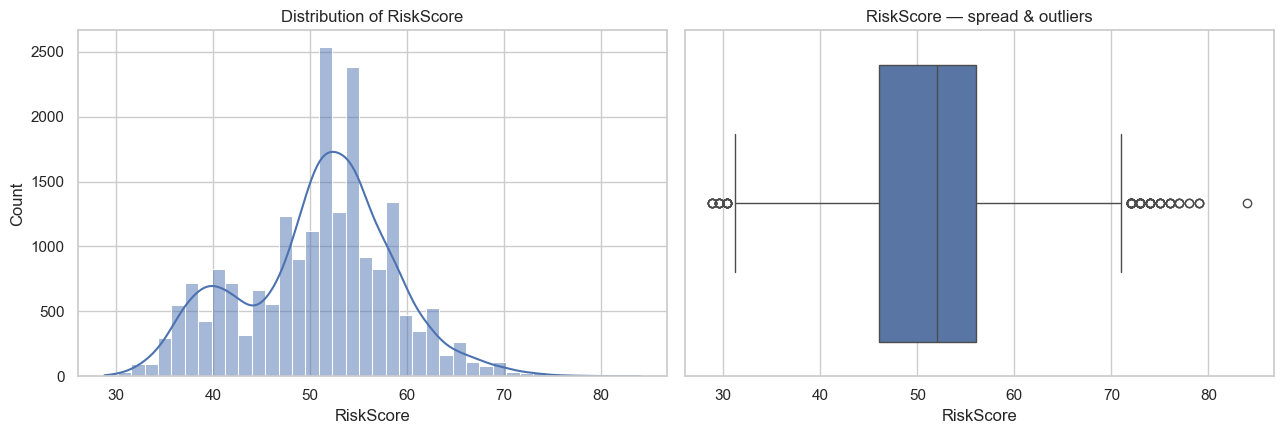

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[TARGET], kde=True, bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of RiskScore")
axes[0].set_xlabel("RiskScore")
axes[0].set_ylabel("Count")

sns.boxplot(x=df[TARGET], ax=axes[1], color="#4C72B0")
axes[1].set_title("RiskScore — spread & outliers")
axes[1].set_xlabel("RiskScore")

plt.tight_layout()
plt.savefig("target_distribution.png", bbox_inches="tight")
plt.show()

**Observation.** `RiskScore` is unimodal and roughly bell-shaped, centred around 50, with a
slightly longer right tail (a handful of applicants score above 75). The boxplot flags a modest
number of high-end outliers but no implausible values (nothing below 0 or above 100), so these
look like genuinely high-risk applicants rather than data-entry errors — they are examined
quantitatively in Section B1 rather than discarded on sight.

#### Numeric feature distributions

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_cols if c != TARGET]
print(f"{len(numeric_features)} numeric features:")
print(numeric_features)

29 numeric features:
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved']


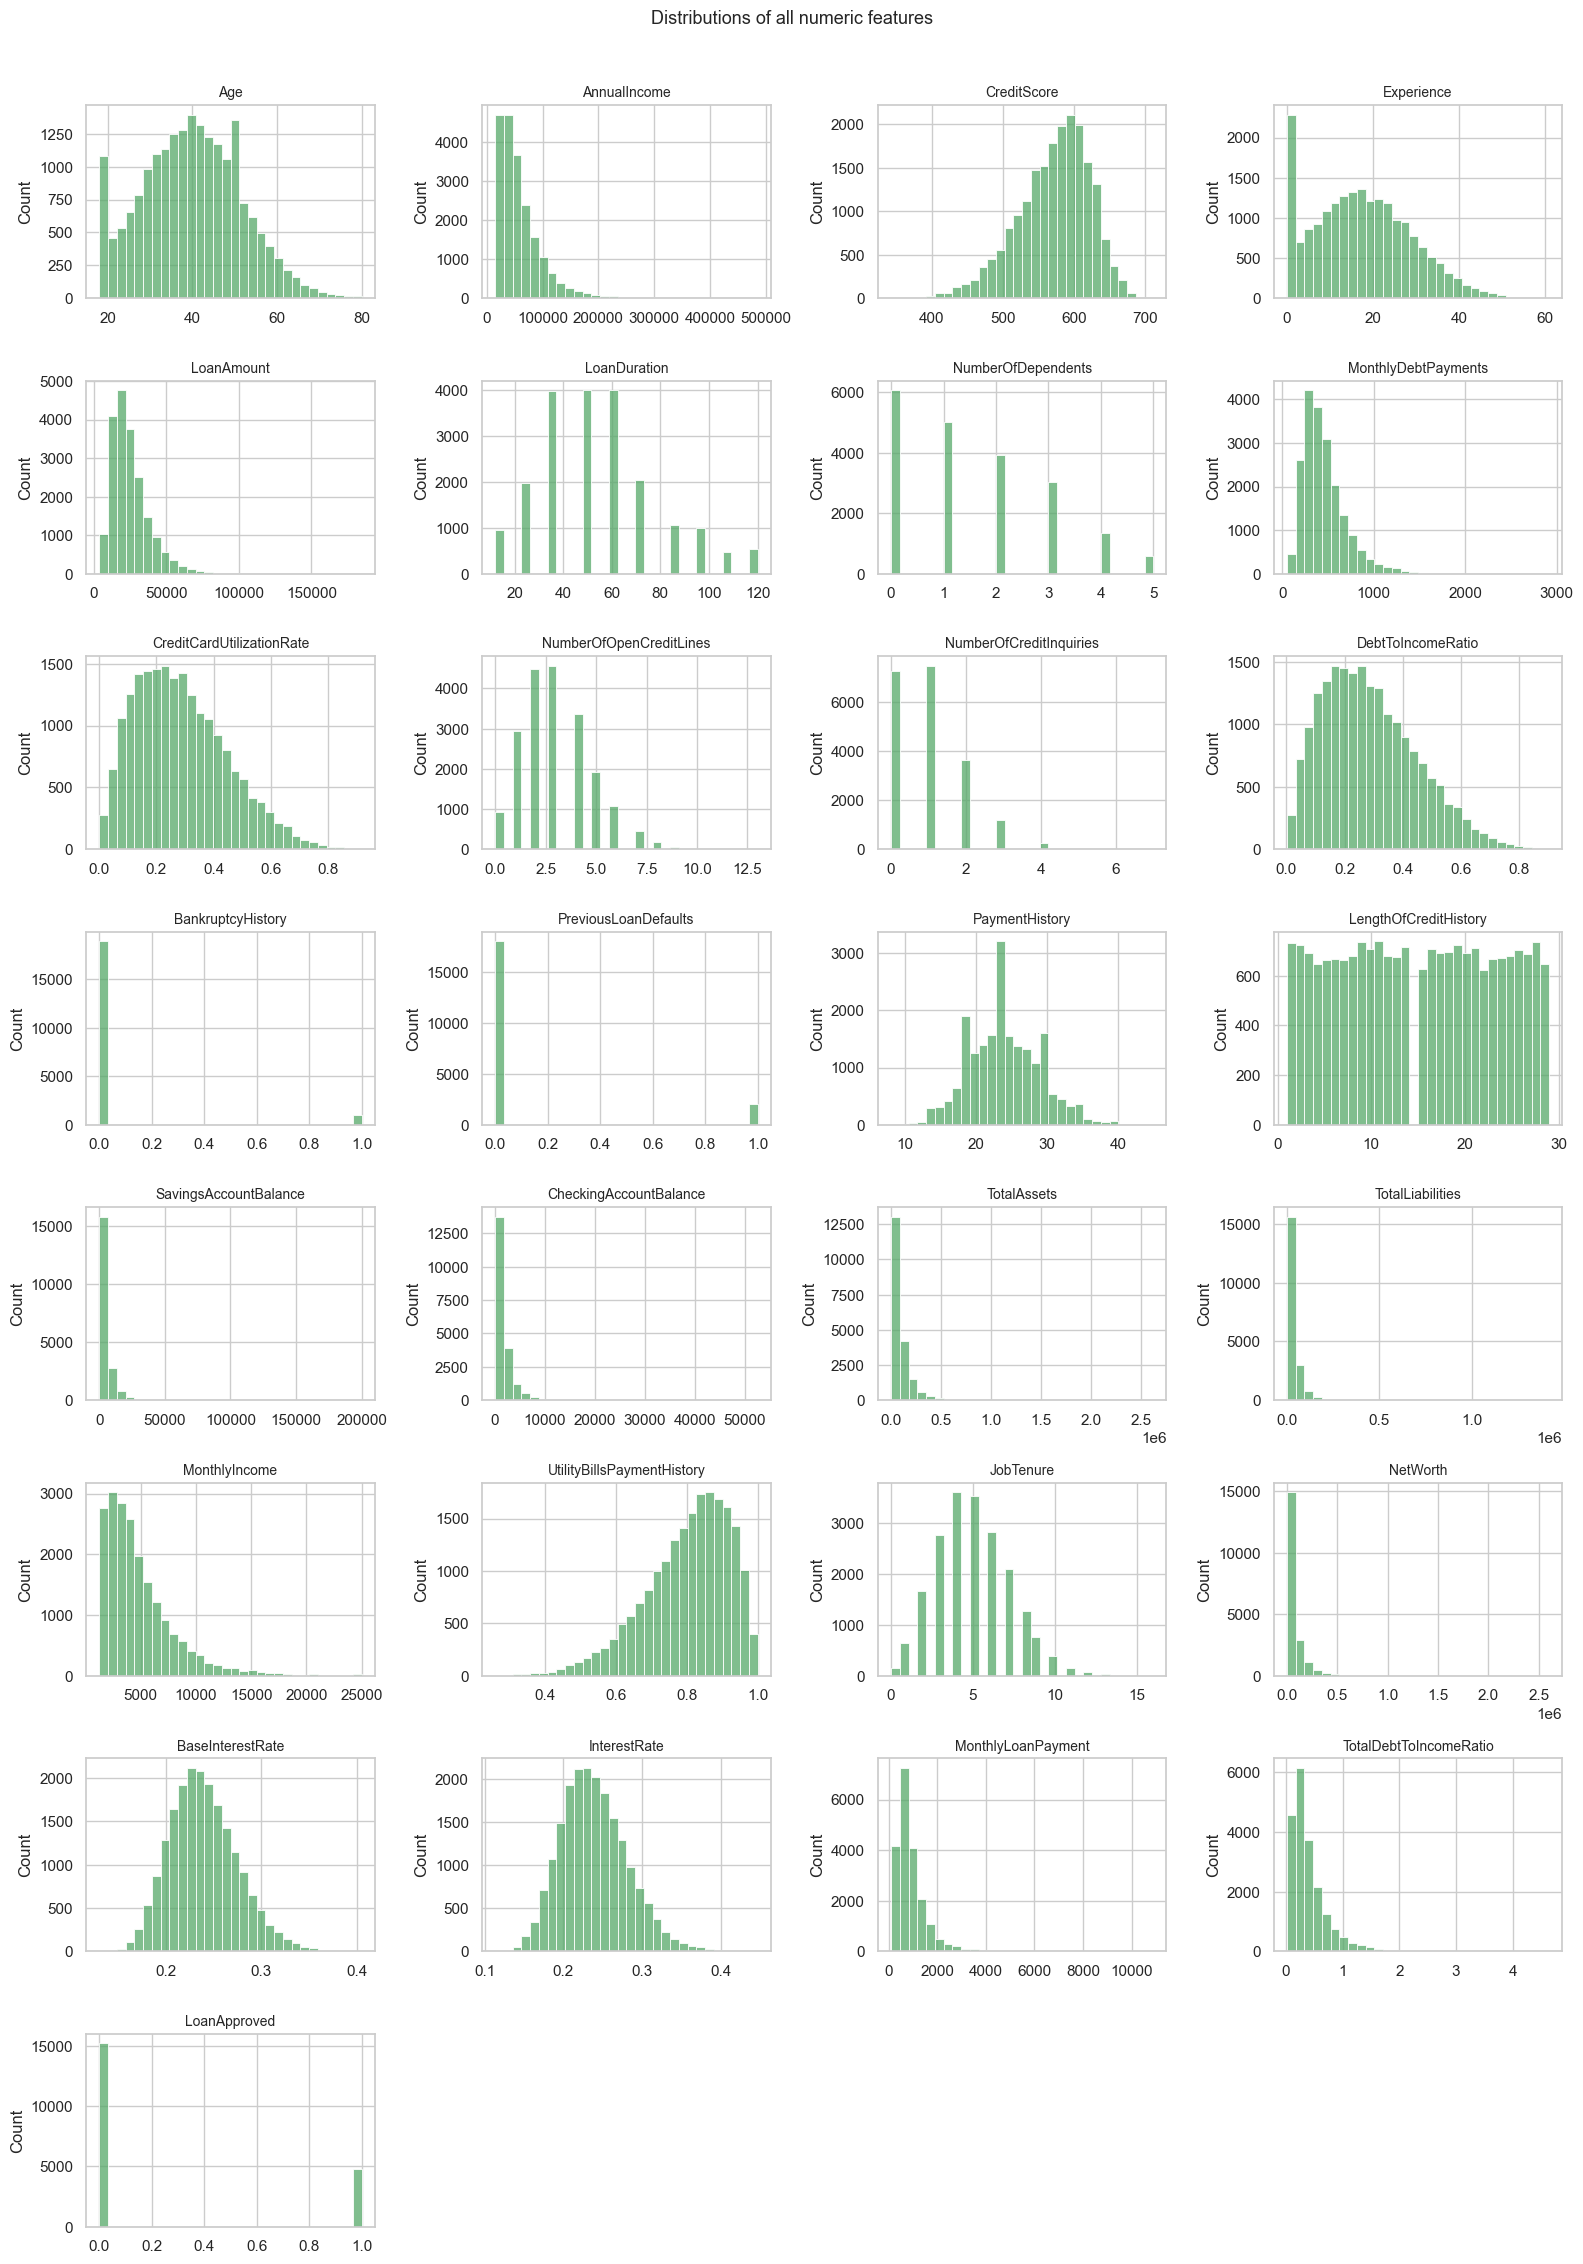

In [9]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.8 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], bins=30, ax=ax, color="#55A868")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

for ax in axes[len(numeric_features):]:
    ax.axis("off")

fig.suptitle("Distributions of all numeric features", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("numeric_feature_distributions.png", bbox_inches="tight")
plt.show()

**Observation.** Most demographic/behavioural fields (`Age`, `CreditScore`,
`LengthOfCreditHistory`, `PaymentHistory`) look approximately normal. Monetary fields
(`AnnualIncome`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`,
`TotalLiabilities`, `NetWorth`, `MonthlyLoanPayment`) are strongly **right-skewed** with long
tails, which is expected for income/wealth-type variables and motivates scaling in Section B2 and
outlier capping in Section B1. `BankruptcyHistory` and `PreviousLoanDefaults` are visibly binary
(two spikes) rather than continuous — they are treated as flags, not as candidates for outlier
capping, later in the notebook.

#### Categorical feature distributions

In [10]:
categorical_features = df.select_dtypes(include="object").columns.tolist()
categorical_features = [c for c in categorical_features if c != "ApplicationDate"]
print(f"{len(categorical_features)} categorical features:")
print(categorical_features)

5 categorical features:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


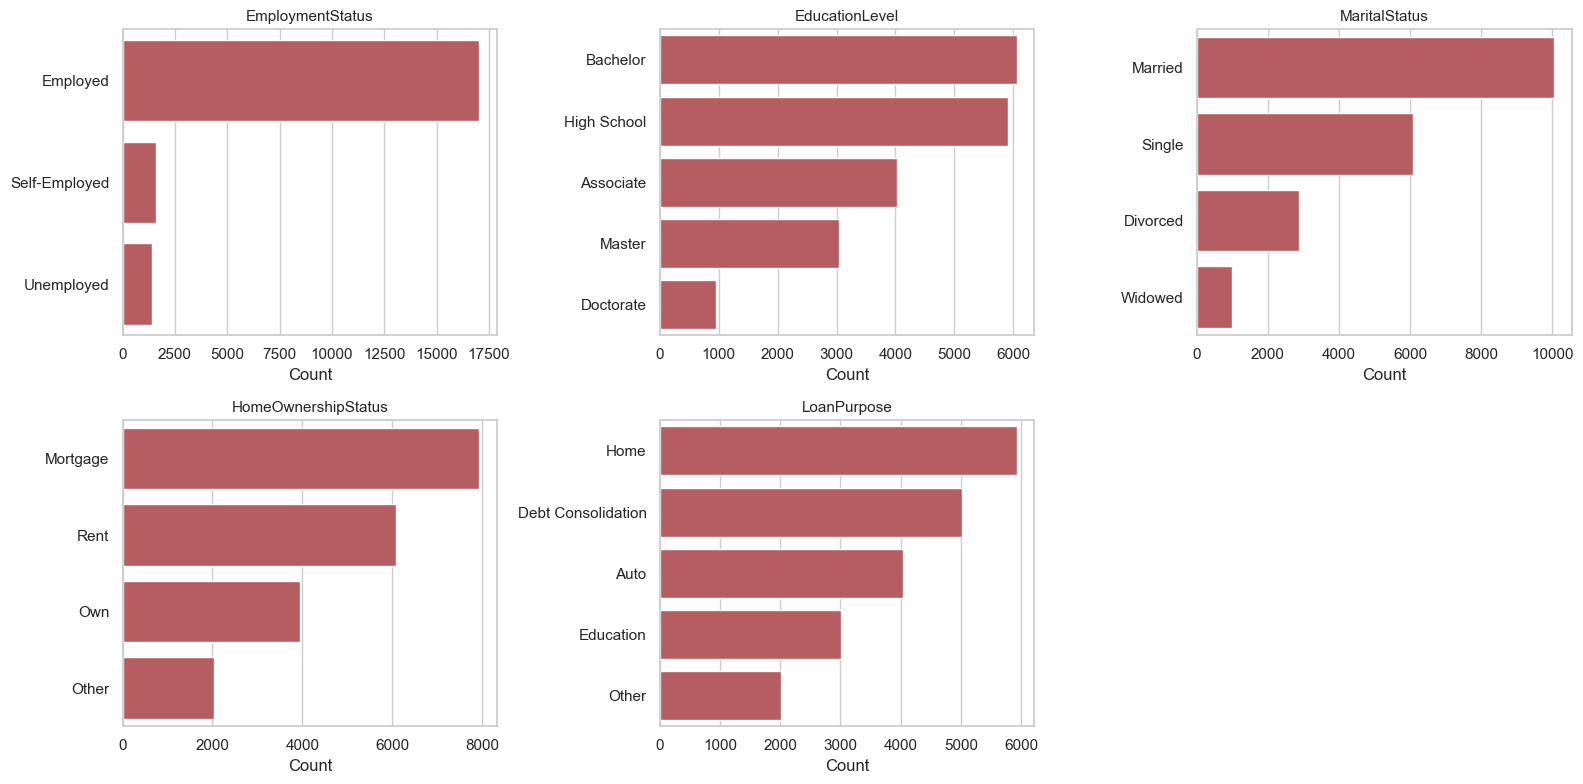

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#C44E52")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

for ax in axes[len(categorical_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("categorical_feature_distributions.png", bbox_inches="tight")
plt.show()

**Observation.** `EmploymentStatus` is dominated by "Employed" applicants, with
"Self-Employed" and "Unemployed" much rarer. `EducationLevel` has a natural order (High School →
Associate → Bachelor → Master → Doctorate) and is reasonably spread across categories, which is
why it is ordinal-encoded rather than one-hot-encoded in Section B2. `MaritalStatus`,
`HomeOwnershipStatus`, and `LoanPurpose` are all nominal with no dominant single category, so
one-hot encoding is the appropriate choice for them.

In [ ]:
#### Correlation heatmap

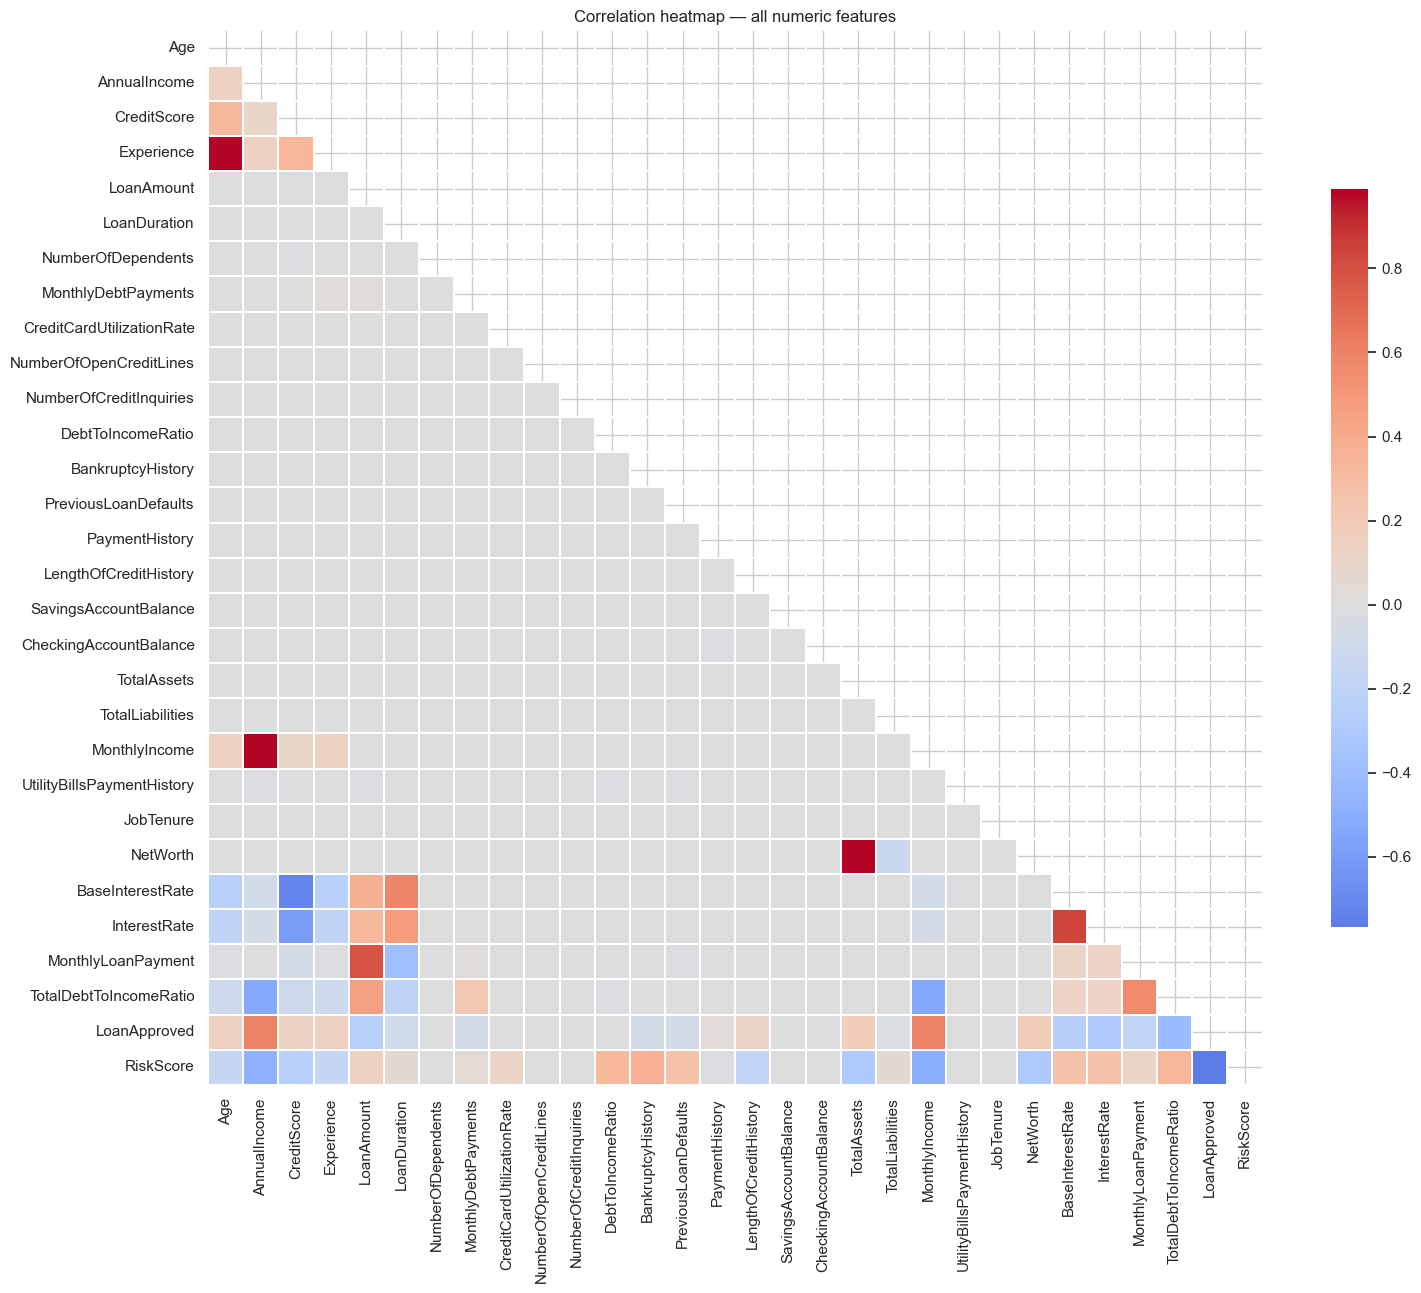

In [12]:
plt.figure(figsize=(16, 13))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=False,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap — all numeric features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [13]:
corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False).to_frame(name="corr_with_RiskScore")

,corr_with_RiskScore
LoanApproved,-0.766137
MonthlyIncome,-0.487039
AnnualIncome,-0.483289
BankruptcyHistory,0.377578
TotalDebtToIncomeRatio,0.342643
DebtToIncomeRatio,0.326500
NetWorth,-0.304333
TotalAssets,-0.297117
InterestRate,0.268203
PreviousLoanDefaults,0.258659
